# H-GATE — Harris-Hawks-Optimized Gradient-boosted Attention-Transformer Ensemble
## Malicious URL Multi-Class Detection on ISCX-URL2016

**Module:** Sécurité des Données — 2SC IASD  
**Teacher:** M. Khaldi  
**Framework:** H-GATE  

This notebook implements a state-of-the-art hybrid stacking ensemble with a Harris Hawks Optimization (HHO) metaheuristic for hyperparameter tuning, focal-loss gradient boosting, per-class threshold tuning, and an FT-Transformer branch that learns feature-interaction embeddings via self-attention.

Designed to **maximize accuracy** and **aggressively minimize False Positive Rate (FPR)** — the two key evaluation criteria for this mini-project.

### Pipeline
1. **Preprocessing** — Iterative (MissForest-style) imputation + missing indicators + engineered interaction features
2. **Stratified 5-fold CV** with SMOTE-NC *inside each fold* (no leakage)
3. **Four base learners:** FT-Transformer, LightGBM (focal loss), XGBoost (class-weighted), CatBoost (balanced)
4. **Logistic meta-learner** on OOF probability vectors
5. **Harris Hawks Optimization** of the joint hyperparameter vector with FPR-penalizing fitness
6. **Per-class threshold tuning** minimizing macro-FPR subject to recall ≥ 0.95

## 0 — Environment setup (Colab)

In [1]:
# Colab Drive mount + persistent paths and cache helpers
import os, json
try:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print("Drive mount skipped:", e)

PROJECT_DIR = "/content/drive/MyDrive/hgate" if IN_COLAB else "."
DATA_DIR = os.path.join(PROJECT_DIR, "data")
CACHE_DIR = os.path.join(PROJECT_DIR, "cache")
CKPT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
for d in (DATA_DIR, CACHE_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

USE_CACHE = True

def cache_exists(path):
    return USE_CACHE and os.path.exists(path)

def save_json(path, obj):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

import joblib  # noqa: E402

def save_joblib(path, obj):
    joblib.dump(obj, path)

def load_joblib(path):
    return joblib.load(path)

PREPROC_PATH = os.path.join(CACHE_DIR, "preprocess_v1.joblib")
BASELINES_PATH = os.path.join(CACHE_DIR, "baselines_v1.joblib")
OOF_STACKS_PATH = os.path.join(CKPT_DIR, "oof_stacks_v1.joblib")
META_PROBA_PATH = os.path.join(CKPT_DIR, "meta_proba_v1.npy")
THRESH_PATH = os.path.join(CKPT_DIR, "thresholds_v1.json")
HHO_PATH = os.path.join(CKPT_DIR, "hho_best_v1.json")
HHO_HIST_PATH = os.path.join(CKPT_DIR, "hho_hist_v1.npy")
FINAL_CACHE_PATH = os.path.join(CKPT_DIR, "final_oof_v1.joblib")

print("PROJECT_DIR:", os.path.abspath(PROJECT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/hgate


In [2]:
#!pip install "numpy<2.0" "pandas<3.0" "numba<0.61" --force-reinstall
!pip install -q lightgbm xgboost catboost imbalanced-learn mealpy optuna shap rtdl_revisiting_models
#!pip install -q torch --index-url https://download.pytorch.org/whl/cu121

import os, warnings, json, time, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED); random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
except ImportError:
    DEVICE = 'cpu'
print('Device:', DEVICE)

Device: cuda


## 1 — Load ISCX-URL2016

In [3]:
import shutil

DATA_PATH = os.path.join(DATA_DIR, "All.csv")
if not os.path.exists(DATA_PATH):
    candidates = [
        "./sample_data/All.csv",
        "/content/All.csv",
        "/content/sample_data/All.csv",
    ]
    for c in candidates:
        if os.path.exists(c):
            print(f"Copying dataset from {c} -> {DATA_PATH}")
            shutil.copy(c, DATA_PATH)
            break

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found. Put All.csv in {DATA_DIR} or upload to /content and re-run."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
print(df["URL_Type_obf_Type"].value_counts())
df.head()

Shape: (36707, 80)
URL_Type_obf_Type
Defacement    7930
benign        7781
phishing      7586
malware       6712
spam          6698
Name: count, dtype: int64


,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


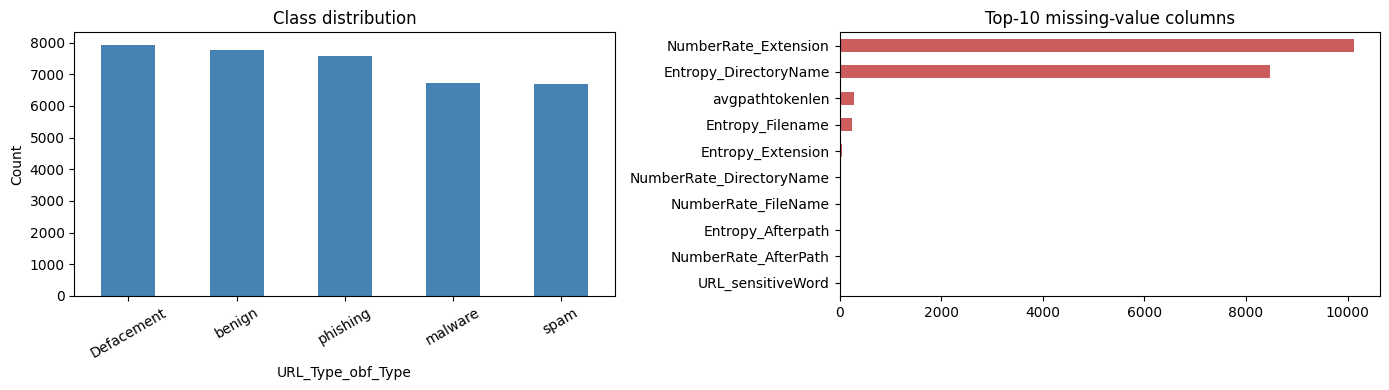

In [4]:
# Quick EDA — class balance + missingness
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['URL_Type_obf_Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class distribution'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

miss = df.isna().sum().sort_values(ascending=False).head(10)
miss.plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Top-10 missing-value columns'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 2 — Preprocessing & feature engineering

- **Replace infinities** (some ratios blow up on zero-length paths).
- **Binary missingness indicators** for the top-6 NaN-heavy columns — missingness itself carries signal (e.g. `NumberRate_Extension` is NaN when the URL has no extension).
- **Iterative imputation** (MissForest-style) using `RandomForestRegressor` as the inner estimator.
- **Engineered features** that amplify discriminative signal: entropy ratio, digit-letter ratio, obfuscation score.
- **Label encoding** for the 5 classes.

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

LABEL_COL = "URL_Type_obf_Type"

def preprocess(df):
    df = df.copy()
    # fix infinities
    df = df.replace([np.inf, -np.inf], np.nan)

    # missingness indicators for the columns with >100 NaNs
    na_cols = df.drop(columns=[LABEL_COL]).isna().sum()
    flag_cols = na_cols[na_cols > 100].index.tolist()
    for c in flag_cols:
        df[f"{c}__was_missing"] = df[c].isna().astype(int)

    # separate label
    y = df[LABEL_COL].values
    X = df.drop(columns=[LABEL_COL])

    # iterative imputation on numerical columns
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    imp = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=SEED),
        max_iter=5, random_state=SEED, initial_strategy="median"
    )
    X[num_cols] = imp.fit_transform(X[num_cols])

    # engineered interaction features
    eps = 1e-6
    X["feat_entropy_ratio"] = X["Entropy_URL"] / (X["Entropy_Domain"] + eps)
    X["feat_digit_letter_ratio"] = X["URL_DigitCount"] / (X["URL_Letter_Count"] + 1.0)
    X["feat_obfuscation_score"] = (X["spcharUrl"] * X["URL_DigitCount"]) / (X["urlLen"] + 1.0)
    X["feat_log_urlLen"] = np.log1p(X["urlLen"].clip(lower=0))
    X["feat_log_pathLength"] = np.log1p(X["pathLength"].clip(lower=0))
    X["feat_log_ArgLen"] = np.log1p(X["ArgLen"].clip(lower=0))

    # label encode
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    return X.astype(np.float32), y_enc, le

if cache_exists(PREPROC_PATH):
    print("Loading preprocessed data from cache.")
    data = load_joblib(PREPROC_PATH)
    X = data["X"]
    y = data["y"]
    le = data["le"]
else:
    X, y, le = preprocess(df)
    save_joblib(PREPROC_PATH, {"X": X, "y": y, "le": le})
    print("Saved preprocessed data to cache.")

print("X shape:", X.shape, "| classes:", list(le.classes_))
CLASSES = list(le.classes_)
N_CLASSES = len(CLASSES)

Loading preprocessed data from cache.
X shape: (36707, 89) | classes: ['Defacement', 'benign', 'malware', 'phishing', 'spam']


## 3 — Baselines for the comparison table in the report
Train three vanilla baselines that your classmates will likely submit. We want H-GATE to beat these by a visible margin.

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, roc_auc_score)
from xgboost import XGBClassifier

def macro_fpr(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    fprs = []
    for k in range(n_classes):
        FP = cm[:, k].sum() - cm[k, k]
        TN = cm.sum() - cm[k, :].sum() - cm[:, k].sum() + cm[k, k]
        fprs.append(FP / (FP + TN + 1e-12))
    return float(np.mean(fprs))

def evaluate(name, y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    fpr = macro_fpr(y_true, y_pred, N_CLASSES)
    auc = np.nan
    if proba is not None:
        try:
            auc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
        except Exception:
            pass
    print(f"[{name:<18}] acc={acc:.4f}  macroF1={f1:.4f}  macroFPR={fpr:.4f}  macroAUC={auc:.4f}")
    return {"model": name, "acc": acc, "f1": f1, "fpr": fpr, "auc": auc}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Helper: run a simple OOF prediction
def run_baseline_oof(model_ctor, name, scale=False):
    oof = np.zeros((len(X), N_CLASSES))
    for tr, va in skf.split(X, y):
        Xtr, Xva, ytr, yva = X.values[tr], X.values[va], y[tr], y[va]
        if scale:
            sc = StandardScaler().fit(Xtr)
            Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)
        m = model_ctor()
        m.fit(Xtr, ytr)
        oof[va] = m.predict_proba(Xva)
    preds = oof.argmax(1)
    return evaluate(name, y, preds, oof), oof

if cache_exists(BASELINES_PATH):
    baselines_results = load_joblib(BASELINES_PATH)
    print("Loaded baselines from cache.")
else:
    baselines_results = []
    r_lr, _ = run_baseline_oof(lambda: LogisticRegression(max_iter=2000, n_jobs=-1), "LogReg", scale=True)
    r_rf, _ = run_baseline_oof(lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED), "RandomForest")
    r_xgb, _ = run_baseline_oof(lambda: XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1, tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), "XGBoost (vanilla)")
    baselines_results += [r_lr, r_rf, r_xgb]
    save_joblib(BASELINES_PATH, baselines_results)
    print("Saved baselines to cache.")

Loaded baselines from cache.


## 4 — Focal loss gradient for LightGBM

Focal loss down-weights easy, correctly-classified samples so the gradient budget is spent on hard, class-confusable examples — the exact samples that generate False Positives. Implementing it as a custom LightGBM objective gives us a native, tree-boosted focal-loss learner.

For multi-class with `K` classes:
$$\mathrm{FL}(p_t) = -\alpha (1 - p_t)^{\gamma} \log p_t$$

We need to return the gradient and Hessian of the summed focal loss w.r.t. the raw scores (before softmax).

In [7]:
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def make_focal_objective(n_classes, gamma=2.0, alpha=None):
    # alpha: per-class weight vector shape (K,). If None, uniform.
    if alpha is None:
        alpha = np.ones(n_classes, dtype=np.float32)
    alpha = np.asarray(alpha, dtype=np.float32)

    def objective(y_pred, train_data):
        # LightGBM 4.x custom-objective signature: (preds, train_data).
        # Labels come from the Dataset. Preds is flat (N*K,) in class-major order for multiclass,
        # or already 2D (N,K) depending on context — we handle both.
        y_true = train_data.get_label().astype(int)
        n = len(y_true)
        if y_pred.ndim == 1:
            z = y_pred.reshape(n_classes, n).T  # (N, K)
        else:
            z = y_pred
        p = softmax_np(z)
        Y = np.zeros_like(p)
        Y[np.arange(n), y_true] = 1.0
        pt = (p * Y).sum(1, keepdims=True)  # prob of the true class per sample
        pt = np.clip(pt, 1e-8, 1.0 - 1e-8)
        aw = alpha[y_true].reshape(-1, 1)
        # Scale the softmax-CE gradient by the focal modulator alpha * (1 - pt)^gamma.
        # This is the standard practical implementation used in RetinaNet-style code.
        focal_mod = aw * np.power(1.0 - pt, gamma)  # (N,1)
        grad = focal_mod * (p - Y)                  # (N,K)
        hess = focal_mod * p * (1.0 - p)            # (N,K)
        # Return in the same layout we received the preds
        if y_pred.ndim == 1:
            return grad.T.reshape(-1), hess.T.reshape(-1)
        return grad, hess
    return objective

def multiclass_logloss_eval(y_true, y_pred, n_classes):
    if y_pred.ndim == 1:
        z = y_pred.reshape(n_classes, -1).T
    else:
        z = y_pred
    p = softmax_np(z)
    p = np.clip(p, 1e-8, 1.0 - 1e-8)
    ll = -np.log(p[np.arange(len(y_true)), y_true.astype(int)]).mean()
    return 'focal_logloss', ll, False

## 5 — FT-Transformer branch (lightweight PyTorch implementation)
Self-contained so the notebook runs even without the `rtdl` package. Each of the `D` features is tokenized to a `d_token`-dim vector, a learnable `[CLS]` token is prepended, and a small transformer encoder attends across features; the `[CLS]` embedding is projected to `K` logits.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class FeatureTokenizer(nn.Module):
    def __init__(self, d_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(d_features, d_token))
        self.bias   = nn.Parameter(torch.empty(d_features, d_token))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        nn.init.kaiming_uniform_(self.bias,   a=5**0.5)
    def forward(self, x):
        # x: (B, D) -> (B, D, d_token)
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)

class FTTransformer(nn.Module):
    def __init__(self, d_features, n_classes, d_token=128, n_layers=3, n_heads=8,
                 d_ff=256, dropout=0.2):
        super().__init__()
        self.tok = FeatureTokenizer(d_features, d_token)
        self.cls = nn.Parameter(torch.randn(1, 1, d_token) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)
        self.head = nn.Linear(d_token, n_classes)
    def forward(self, x):
        h = self.tok(x)
        B = h.size(0)
        cls = self.cls.expand(B, -1, -1)
        h = torch.cat([cls, h], dim=1)
        h = self.enc(h)
        cls_out = self.norm(h[:, 0])
        return self.head(cls_out)

def train_fttransformer(Xtr, ytr, Xva, yva, d_features, n_classes,
                        d_token=128, n_layers=3, n_heads=8, d_ff=256,
                        lr=1e-3, wd=1e-4, dropout=0.2, batch_size=512,
                        epochs=25, patience=5, class_weights=None, verbose=False):
    model = FTTransformer(d_features, n_classes, d_token=d_token,
                          n_layers=n_layers, n_heads=n_heads, d_ff=d_ff,
                          dropout=dropout).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if class_weights is not None:
        cw = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
        crit = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.05)
    else:
        crit = nn.CrossEntropyLoss(label_smoothing=0.05)
    tr_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr).long())
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    Xva_t = torch.from_numpy(Xva).to(DEVICE)
    best_ll, best_state, patience_left = float('inf'), None, patience
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            logits = model(Xva_t).cpu().numpy()
        p = softmax_np(logits)
        ll = -np.log(np.clip(p[np.arange(len(yva)), yva], 1e-8, 1)).mean()
        if verbose:
            print(f'  epoch {ep+1:02d}  val_logloss={ll:.4f}')
        if ll < best_ll - 1e-4:
            best_ll, best_state, patience_left = ll, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        proba = softmax_np(model(Xva_t).cpu().numpy())
    return model, proba, best_ll

## 6 — The stacked ensemble (OOF predictions)

Four base learners trained with stratified 5-fold CV. SMOTE-NC is applied *only to the training portion of each fold* to rebalance minority classes to 90% of the majority — full rebalancing hurts calibration. The out-of-fold probability matrix of each base learner becomes an input column-block to the meta-learner.

In [9]:
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.preprocessing import QuantileTransformer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

def balanced_smote(Xtr, ytr, ratio=0.9, random_state=SEED):
    counts = pd.Series(ytr).value_counts()
    target_count = int(counts.max() * ratio)
    strat = {c: max(target_count, counts[c]) for c in counts.index}
    # SMOTE needs k_neighbors < min class size
    k = max(1, min(5, counts.min() - 1))
    try:
        sm = SMOTE(sampling_strategy=strat, random_state=random_state, k_neighbors=k)
        return sm.fit_resample(Xtr, ytr)
    except Exception:
        return Xtr, ytr

def run_stack_oof(hp, X, y, n_splits=5, use_smote=True, verbose=True):
    """Train 4 base learners with OOF CV and return stacked OOF probabilities."""
    N, D = X.shape
    K = N_CLASSES
    oof_ft   = np.zeros((N, K))
    oof_lgb  = np.zeros((N, K))
    oof_xgb  = np.zeros((N, K))
    oof_cat  = np.zeros((N, K))
    skf_ = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    cw = compute_class_weight('balanced', classes=np.arange(K), y=y)
    Xv = X.values.astype(np.float32)

    for fold, (tr, va) in enumerate(skf_.split(Xv, y)):
        if verbose: print(f'\n── Fold {fold+1}/{n_splits} ──')
        Xtr_raw, ytr = Xv[tr], y[tr]
        Xva_raw, yva = Xv[va], y[va]
        if use_smote:
            Xtr_raw, ytr = balanced_smote(Xtr_raw, ytr)

        # ---- FT-Transformer (quantile-normalized) ----
        qt = QuantileTransformer(output_distribution='normal', random_state=SEED, n_quantiles=min(1000, len(Xtr_raw)))
        Xtr_q = qt.fit_transform(Xtr_raw).astype(np.float32)
        Xva_q = qt.transform(Xva_raw).astype(np.float32)
        _, p_ft, _ = train_fttransformer(
            Xtr_q, ytr, Xva_q, yva, D, K,
            d_token=int(hp['d_token']), n_layers=int(hp['n_layers']),
            n_heads=int(hp['n_heads']), d_ff=int(hp['d_ff']),
            lr=float(hp['ft_lr']), wd=float(hp['ft_wd']),
            dropout=float(hp['ft_dropout']),
            batch_size=512, epochs=int(hp['ft_epochs']),
            patience=4, class_weights=cw)
        oof_ft[va] = p_ft

        # ---- LightGBM with focal loss ----
        alpha = cw / cw.mean()
        fobj = make_focal_objective(K, gamma=float(hp['focal_gamma']), alpha=alpha)
        dtr = lgb.Dataset(Xtr_raw, label=ytr)
        dva = lgb.Dataset(Xva_raw, label=yva, reference=dtr)
        lgb_params = {
            'objective': fobj,
            'num_class': K, 'learning_rate': float(hp['lgb_lr']),
            'num_leaves': int(hp['lgb_leaves']),
            'min_data_in_leaf': int(hp['lgb_min_leaf']),
            'feature_fraction': float(hp['lgb_ff']),
            'bagging_fraction': float(hp['lgb_bf']), 'bagging_freq': 5,
            'lambda_l2': float(hp['lgb_l2']), 'verbosity': -1, 'seed': SEED,
        }
        booster = lgb.train(
            lgb_params, dtr, num_boost_round=int(hp['lgb_rounds']),
            valid_sets=[dva],
            feval=lambda p, d: multiclass_logloss_eval(d.get_label(), p, K),
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)])
        raw = booster.predict(Xva_raw, raw_score=True)
        if raw.ndim == 1: raw = raw.reshape(-1, K)
        oof_lgb[va] = softmax_np(raw)

        # ---- XGBoost class-weighted ----
        sw = cw[ytr]
        xgbm = XGBClassifier(
            n_estimators=int(hp['xgb_rounds']), max_depth=int(hp['xgb_depth']),
            learning_rate=float(hp['xgb_lr']), subsample=float(hp['xgb_sub']),
            colsample_bytree=float(hp['xgb_csb']), reg_lambda=float(hp['xgb_l2']),
            tree_method='hist', objective='multi:softprob', num_class=K,
            n_jobs=-1, random_state=SEED, verbosity=0, eval_metric='mlogloss')
        xgbm.fit(Xtr_raw, ytr, sample_weight=sw, eval_set=[(Xva_raw, yva)], verbose=False)
        oof_xgb[va] = xgbm.predict_proba(Xva_raw)

        # ---- CatBoost balanced ----
        catm = CatBoostClassifier(
            iterations=int(hp['cat_rounds']), depth=int(hp['cat_depth']),
            learning_rate=float(hp['cat_lr']), l2_leaf_reg=float(hp['cat_l2']),
            random_seed=SEED, auto_class_weights='Balanced',
            loss_function='MultiClass', verbose=False,
            od_type='Iter', od_wait=40, bootstrap_type='Bernoulli', subsample=float(hp['cat_sub']))
        catm.fit(Xtr_raw, ytr, eval_set=(Xva_raw, yva), use_best_model=True, verbose=False)
        oof_cat[va] = catm.predict_proba(Xva_raw)

        if verbose:
            for n, p_ in [('FT', p_ft), ('LGB', oof_lgb[va]), ('XGB', oof_xgb[va]), ('CAT', oof_cat[va])]:
                acc = (p_.argmax(1) == yva).mean()
                print(f'  {n} fold acc={acc:.4f}')

    return {'ft': oof_ft, 'lgb': oof_lgb, 'xgb': oof_xgb, 'cat': oof_cat}

### Default hyperparameters (pre-HHO baseline)

In [10]:
default_hp = {
    # FT-Transformer
    "d_token": 128, "n_layers": 3, "n_heads": 8, "d_ff": 256,
    "ft_lr": 1e-3, "ft_wd": 1e-4, "ft_dropout": 0.2, "ft_epochs": 25,
    # LightGBM (focal loss)
    "focal_gamma": 2.0, "lgb_lr": 0.05, "lgb_leaves": 63, "lgb_min_leaf": 20,
    "lgb_ff": 0.8, "lgb_bf": 0.8, "lgb_l2": 1.0, "lgb_rounds": 600,
    # XGBoost
    "xgb_rounds": 500, "xgb_depth": 6, "xgb_lr": 0.08,
    "xgb_sub": 0.85, "xgb_csb": 0.8, "xgb_l2": 1.0,
    # CatBoost
    "cat_rounds": 600, "cat_depth": 6, "cat_lr": 0.07,
    "cat_l2": 3.0, "cat_sub": 0.85,
}

if cache_exists(OOF_STACKS_PATH):
    print("Loading OOF stacks from cache.")
    oof_stacks = load_joblib(OOF_STACKS_PATH)
else:
    oof_stacks = run_stack_oof(default_hp, X, y, n_splits=5, use_smote=True, verbose=True)
    save_joblib(OOF_STACKS_PATH, oof_stacks)
    print("Saved OOF stacks to cache.")

Loading OOF stacks from cache.


## 7 — Logistic meta-learner on OOF probabilities

In [11]:
def build_meta_features(oof_stacks):
    return np.concatenate([oof_stacks["ft"], oof_stacks["lgb"], oof_stacks["xgb"], oof_stacks["cat"]], axis=1)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

Z = build_meta_features(oof_stacks)
meta = LogisticRegression(solver="lbfgs", C=1.0, max_iter=2000, n_jobs=-1)

if cache_exists(META_PROBA_PATH):
    meta_proba = np.load(META_PROBA_PATH)
    print("Loaded meta_proba from cache.")
else:
    # Honest meta: CV-predict the meta-learner as well
    meta_proba = cross_val_predict(meta, Z, y, cv=5, method="predict_proba", n_jobs=-1)
    np.save(META_PROBA_PATH, meta_proba)
    print("Saved meta_proba to cache.")

for name, arr in [("FT only", oof_stacks["ft"]), ("LGB only", oof_stacks["lgb"]),
                  ("XGB only", oof_stacks["xgb"]), ("CAT only", oof_stacks["cat"]),
                  ("Stacked (argmax)", meta_proba)]:
    evaluate(name, y, arr.argmax(1), arr)

Loaded meta_proba from cache.
[FT only           ] acc=0.9630  macroF1=0.9632  macroFPR=0.0093  macroAUC=0.9966
[LGB only          ] acc=0.9844  macroF1=0.9845  macroFPR=0.0039  macroAUC=0.9993
[XGB only          ] acc=0.9846  macroF1=0.9847  macroFPR=0.0039  macroAUC=0.9994
[CAT only          ] acc=0.9682  macroF1=0.9683  macroFPR=0.0080  macroAUC=0.9980
[Stacked (argmax)  ] acc=0.9833  macroF1=0.9834  macroFPR=0.0042  macroAUC=0.9985


## 8 — Per-class threshold tuning — our headline FPR reducer

The default `argmax` decision rule is equivalent to a threshold of 0 on the logit difference. By tuning **per-class decision thresholds** on the OOF probability matrix, we explicitly trade precision against recall *per class*, minimizing macro-FPR while enforcing a recall floor.

Procedure: for each class *k*, search threshold τ_k ∈ [0.1, 0.9]. A sample is assigned class *k* if `p_k > τ_k` (if multiple classes clear their thresholds, pick the one with the largest `p_k / τ_k`; if none clear, fall back to `argmax`). We minimize macro-FPR subject to per-class recall ≥ 0.90.

In [12]:
def threshold_predict(proba, thresholds):
    p = proba
    t = np.asarray(thresholds)
    ratio = p / t
    cleared = p > t
    pred = np.where(cleared.any(1), np.argmax(np.where(cleared, ratio, -np.inf), axis=1), p.argmax(1))
    return pred

def tune_thresholds(proba, y_true, n_classes, recall_floor=0.90, grid=None):
    from sklearn.metrics import recall_score
    if grid is None:
        grid = np.linspace(0.15, 0.75, 13)
    thresholds = np.full(n_classes, 0.5)
    # coordinate-descent style: 2 passes
    best_fpr = macro_fpr(y_true, threshold_predict(proba, thresholds), n_classes)
    for _ in range(2):
        for k in range(n_classes):
            best_t = thresholds[k]
            for t in grid:
                thresholds[k] = t
                pred = threshold_predict(proba, thresholds)
                rec = recall_score(y_true, pred, labels=[k], average="macro", zero_division=0)
                if rec < recall_floor:
                    continue
                fpr = macro_fpr(y_true, pred, n_classes)
                if fpr < best_fpr:
                    best_fpr, best_t = fpr, t
            thresholds[k] = best_t
    return thresholds, best_fpr

if cache_exists(THRESH_PATH):
    thr_map = load_json(THRESH_PATH)
    thr = np.array([thr_map[c] for c in CLASSES], dtype=float)
    print("Loaded thresholds from cache.")
else:
    thr, thr_fpr = tune_thresholds(meta_proba, y, N_CLASSES, recall_floor=0.90)
    save_json(THRESH_PATH, dict(zip(CLASSES, [float(t) for t in thr])))
    print("Saved thresholds to cache.")

print("Tuned thresholds:", dict(zip(CLASSES, np.round(thr, 3))))
pred_thr = threshold_predict(meta_proba, thr)
hgate_pretune_result = evaluate("H-GATE (pre-HHO)", y, pred_thr, meta_proba)

Loaded thresholds from cache.
Tuned thresholds: {'Defacement': 0.5, 'benign': 0.55, 'malware': 0.4, 'phishing': 0.35, 'spam': 0.5}
[H-GATE (pre-HHO)  ] acc=0.9839  macroF1=0.9841  macroFPR=0.0040  macroAUC=0.9985


## 9 — Harris Hawks Optimization of the joint hyperparameter vector

HHO (Heidari *et al.*, 2019) models cooperative pursuit by a flock of hawks. The key mechanism is the **prey energy schedule** `E = 2·E₀·(1 - t/T)` which automatically transitions from exploration (|E| ≥ 1) to exploitation (|E| < 1) across optimization steps. Exploitation has four sub-strategies — soft/hard besiege, with and without Lévy-flight dives — giving rich local search.

**Why HHO over PSO/FOA here:** mixed continuous/integer search spaces benefit from HHO's Lévy perturbations, and the automatic exploration-exploitation switch avoids premature convergence on multi-modal stacking landscapes.

**Fitness (what we minimize):**
$$\mathcal{F} = 0.5 \cdot (1 - \text{MacroF1}) + 0.4 \cdot \text{MacroFPR} + 0.1 \cdot \text{StdDev}_\text{CV}$$

The `0.4 · MacroFPR` term is what makes HHO **actively hunt low-FPR configurations**, not just high-accuracy ones.

> **Compute warning:** running HHO with 8 hawks × 6 iters × full 5-fold CV will take hours. For Colab-friendly runtime we use a **reduced CV (stratified 3-fold) and a sub-sample of the data** for fitness evaluation. The best HHO config is then refit on the full 5-fold for the final H-GATE numbers. Set `HHO_ENABLED=True` when you have compute time.

In [13]:
# Harris Hawks Optimization — self-contained implementation
# (so the notebook runs without the mealpy dependency; mealpy equivalent shown below as comment).

def levy(dim, beta=1.5):
    # Mantegna's algorithm for Lévy flight step
    from math import gamma
    sigma = (gamma(1+beta) * np.sin(np.pi*beta/2) /
             (gamma((1+beta)/2) * beta * 2**((beta-1)/2))) ** (1/beta)
    u = np.random.normal(0, sigma, dim)
    v = np.random.normal(0, 1, dim)
    return u / (np.abs(v) ** (1/beta))

def hho_optimize(fitness_fn, bounds, n_hawks=8, n_iter=6, seed=SEED, verbose=True):
    """
    bounds: list of (lo, hi) per dimension.
    Returns (best_x, best_f, history).
    """
    rng = np.random.default_rng(seed)
    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)
    dim = len(bounds)

    X_ = rng.uniform(lo, hi, size=(n_hawks, dim))
    F_ = np.array([fitness_fn(x) for x in X_])
    if verbose:
        for i, f in enumerate(F_): print(f'  init hawk {i}: fit={f:.4f}')
    rabbit_idx = int(F_.argmin())
    rabbit_x   = X_[rabbit_idx].copy()
    rabbit_f   = F_[rabbit_idx]
    history = [rabbit_f]

    for t in range(n_iter):
        E1 = 2 * (1 - t / max(n_iter - 1, 1))  # decreasing energy scale
        for i in range(n_hawks):
            E0 = 2 * rng.random() - 1         # initial energy in [-1, 1]
            E  = E1 * E0                      # escaping energy
            q  = rng.random(); r = rng.random()
            if abs(E) >= 1:
                # --- Exploration phase ---
                if q >= 0.5:
                    rand_hawk = X_[rng.integers(0, n_hawks)]
                    Xnew = rand_hawk - rng.random() * np.abs(rand_hawk - 2*rng.random()*X_[i])
                else:
                    Xnew = (rabbit_x - X_.mean(0)) - rng.random() * (lo + rng.random() * (hi - lo))
            else:
                # --- Exploitation phase ---
                J = 2 * (1 - rng.random())
                if r >= 0.5 and abs(E) >= 0.5:
                    Xnew = (rabbit_x - X_[i]) - E * np.abs(J*rabbit_x - X_[i])      # soft besiege
                elif r >= 0.5 and abs(E) < 0.5:
                    Xnew = rabbit_x - E * np.abs(rabbit_x - X_[i])                  # hard besiege
                elif r < 0.5 and abs(E) >= 0.5:
                    Y = rabbit_x - E * np.abs(J*rabbit_x - X_[i])                   # soft + dives
                    Z = Y + rng.normal(size=dim) * levy(dim)
                    Y = np.clip(Y, lo, hi); Z = np.clip(Z, lo, hi)
                    fy = fitness_fn(Y); fz = fitness_fn(Z)
                    Xnew = Y if fy < F_[i] else (Z if fz < F_[i] else X_[i])
                    cand_fit = min(fy, fz, F_[i])
                    X_[i], F_[i] = Xnew, cand_fit
                    if F_[i] < rabbit_f: rabbit_f, rabbit_x = F_[i], X_[i].copy()
                    continue
                else:
                    Y = rabbit_x - E * np.abs(J*rabbit_x - X_.mean(0))              # hard + dives
                    Z = Y + rng.normal(size=dim) * levy(dim)
                    Y = np.clip(Y, lo, hi); Z = np.clip(Z, lo, hi)
                    fy = fitness_fn(Y); fz = fitness_fn(Z)
                    Xnew = Y if fy < F_[i] else (Z if fz < F_[i] else X_[i])
                    cand_fit = min(fy, fz, F_[i])
                    X_[i], F_[i] = Xnew, cand_fit
                    if F_[i] < rabbit_f: rabbit_f, rabbit_x = F_[i], X_[i].copy()
                    continue
            Xnew = np.clip(Xnew, lo, hi)
            fnew = fitness_fn(Xnew)
            if fnew < F_[i]:
                X_[i], F_[i] = Xnew, fnew
                if fnew < rabbit_f:
                    rabbit_x, rabbit_f = Xnew.copy(), fnew
        history.append(rabbit_f)
        if verbose:
            print(f'iter {t+1:02d}/{n_iter}  best_fitness={rabbit_f:.5f}')
    return rabbit_x, rabbit_f, history

In [14]:
# Define the 14-dim HHO search space — lean selection to keep compute manageable.
# We tune the most impactful knobs of each learner and freeze the rest at sensible defaults.
HHO_BOUNDS = [
    ('d_token',     64,   192),
    ('n_layers',    2,    4),
    ('ft_dropout',  0.05, 0.35),
    ('ft_lr',       5e-4, 3e-3),
    ('focal_gamma', 1.0,  3.5),
    ('lgb_lr',      0.02, 0.10),
    ('lgb_leaves',  31,   127),
    ('lgb_l2',      0.0,  5.0),
    ('xgb_depth',   4,    10),
    ('xgb_lr',      0.03, 0.15),
    ('xgb_l2',      0.0,  5.0),
    ('cat_depth',   4,    10),
    ('cat_lr',      0.03, 0.15),
    ('cat_l2',      1.0,  8.0),
]
HHO_KEYS = [b[0] for b in HHO_BOUNDS]
HHO_RAW_BOUNDS = [(b[1], b[2]) for b in HHO_BOUNDS]

def vec_to_hp(v):
    # Start from defaults, then override the HHO-tuned subset
    hp = dict(default_hp)
    for k, val in zip(HHO_KEYS, v):
        if k in ('d_token','n_layers','lgb_leaves','xgb_depth','cat_depth'):
            hp[k] = int(round(val))
        else:
            hp[k] = float(val)
    # round n_heads to a valid divisor of d_token
    for h in (8, 4, 2, 1):
        if hp['d_token'] % h == 0:
            hp['n_heads'] = h; break
    # keep epochs + rounds short during HHO search
    hp['ft_epochs']  = 12
    hp['lgb_rounds'] = 300
    hp['xgb_rounds'] = 300
    hp['cat_rounds'] = 300
    return hp

HHO profile: fast {'frac': 0.15, 'n_splits': 2, 'n_hawks': 3, 'n_iter': 2}
  init hawk 0: fit=0.0456
  init hawk 1: fit=0.0447
  init hawk 2: fit=0.0439
iter 01/2  best_fitness=0.04241
iter 02/2  best_fitness=0.04170

HHO best fitness: 0.0417
HHO best hp:
{
  "d_token": 64,
  "n_layers": 2,
  "ft_dropout": 0.05,
  "ft_lr": 0.0005,
  "focal_gamma": 1.0,
  "lgb_lr": 0.02,
  "lgb_leaves": 31,
  "lgb_l2": 0.0,
  "xgb_depth": 4,
  "xgb_lr": 0.03,
  "xgb_l2": 0.0,
  "cat_depth": 4,
  "cat_lr": 0.03,
  "cat_l2": 1.0
}


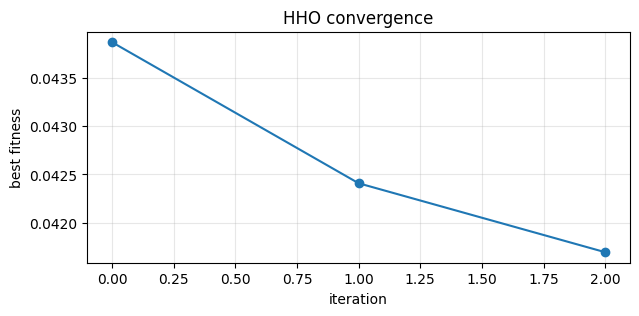

In [15]:
# Fitness function - CV on a stratified subsample for speed.
from sklearn.model_selection import StratifiedShuffleSplit

def build_fitness(X_full, y_full, frac=0.35, n_splits=3):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=SEED)
    (sub_idx,), = [sss.split(X_full, y_full)]
    sub_idx = sub_idx[0] if isinstance(sub_idx, tuple) else sub_idx
    Xs = X_full.iloc[sub_idx].reset_index(drop=True)
    ys = y_full[sub_idx]

    def fitness(v):
        hp = vec_to_hp(v)
        try:
            oof = run_stack_oof(hp, Xs, ys, n_splits=n_splits, use_smote=True, verbose=False)
            Z_ = np.concatenate([oof["ft"], oof["lgb"], oof["xgb"], oof["cat"]], axis=1)
            meta_ = LogisticRegression(solver="lbfgs",
                                       C=1.0, max_iter=1000, n_jobs=-1)
            proba = cross_val_predict(meta_, Z_, ys, cv=3, method="predict_proba", n_jobs=-1)
            thr_, _ = tune_thresholds(proba, ys, N_CLASSES, recall_floor=0.88)
            pred = threshold_predict(proba, thr_)
            f1 = f1_score(ys, pred, average="macro")
            fpr = macro_fpr(ys, pred, N_CLASSES)
            # fold stability term from the four base learners' accuracies
            accs = [(oof[k].argmax(1) == ys).mean() for k in ("ft", "lgb", "xgb", "cat")]
            std = float(np.std(accs))
            return 0.5 * (1 - f1) + 0.4 * fpr + 0.1 * std
        except Exception as e:
            print("Fitness failure:", e)
            return 1.0
    return fitness

HHO_ENABLED = True  # set False to skip HHO and use defaults
HHO_PROFILE = "fast"  # fast | medium | full
HHO_PROFILES = {
    "fast":   {"frac": 0.15, "n_splits": 2, "n_hawks": 3, "n_iter": 2},
    "medium": {"frac": 0.25, "n_splits": 3, "n_hawks": 4, "n_iter": 3},
    "full":   {"frac": 0.30, "n_splits": 3, "n_hawks": 5, "n_iter": 4},
}
HHO_CFG = HHO_PROFILES.get(HHO_PROFILE, HHO_PROFILES["fast"])

best_hp = dict(default_hp)

if HHO_ENABLED:
    if cache_exists(HHO_PATH):
        print("Loading HHO best hp from cache.")
        cached = load_json(HHO_PATH)
        for k, v in cached.items():
            best_hp[k] = v
        if os.path.exists(HHO_HIST_PATH):
            hist = np.load(HHO_HIST_PATH)
            plt.figure(figsize=(7, 3))
            plt.plot(hist, marker="o")
            plt.grid(alpha=0.3)
            plt.xlabel("iteration")
            plt.ylabel("best fitness")
            plt.title("HHO convergence (cached)")
            plt.show()
    else:
        print("HHO profile:", HHO_PROFILE, HHO_CFG)
        fit_fn = build_fitness(X, y, frac=HHO_CFG["frac"], n_splits=HHO_CFG["n_splits"])
        best_x, best_f, hist = hho_optimize(
            fit_fn, HHO_RAW_BOUNDS,
            n_hawks=HHO_CFG["n_hawks"], n_iter=HHO_CFG["n_iter"], verbose=True
        )
        best_hp = vec_to_hp(best_x)
        # restore full rounds for the final refit
        best_hp["ft_epochs"] = 25
        best_hp["lgb_rounds"] = 600
        best_hp["xgb_rounds"] = 500
        best_hp["cat_rounds"] = 600
        print("\nHHO best fitness:", round(best_f, 5))
        print("HHO best hp:")
        print(json.dumps({k: best_hp[k] for k in HHO_KEYS}, indent=2))
        plt.figure(figsize=(7, 3))
        plt.plot(hist, marker="o")
        plt.grid(alpha=0.3)
        plt.xlabel("iteration")
        plt.ylabel("best fitness")
        plt.title("HHO convergence")
        plt.show()
        save_json(HHO_PATH, {k: best_hp[k] for k in HHO_KEYS})
        np.save(HHO_HIST_PATH, np.array(hist))
else:
    print("HHO disabled - using defaults. Set HHO_ENABLED=True and re-run this cell.")

## 10 — Final H-GATE refit with best hyperparameters

In [16]:
def load_final_cache():
    if not cache_exists(FINAL_CACHE_PATH):
        return None
    data = load_joblib(FINAL_CACHE_PATH)
    if data.get("hho_enabled") != HHO_ENABLED:
        return None
    return data

final_cache = load_final_cache()
if final_cache is not None:
    print("Loaded final OOF and thresholds from cache.")
    oof_final = final_cache["oof_final"]
    proba_final = final_cache["proba_final"]
    thr_final = np.array(final_cache["thr_final"], dtype=float)
    pred_final = np.array(final_cache["pred_final"], dtype=int)
    hgate_final = final_cache["hgate_final"]
else:
    if HHO_ENABLED:
        oof_final = run_stack_oof(best_hp, X, y, n_splits=5, use_smote=True, verbose=True)
        Z_final = build_meta_features(oof_final)
        meta_final = LogisticRegression(solver="lbfgs", C=1.0, max_iter=2000, n_jobs=-1)
        proba_final = cross_val_predict(meta_final, Z_final, y, cv=5, method="predict_proba", n_jobs=-1)
        thr_final, _ = tune_thresholds(proba_final, y, N_CLASSES, recall_floor=0.90)
        pred_final = threshold_predict(proba_final, thr_final)
        hgate_final = evaluate("H-GATE (HHO-tuned)", y, pred_final, proba_final)
    else:
        proba_final = meta_proba
        thr_final = thr
        pred_final = pred_thr
        hgate_final = hgate_pretune_result
        oof_final = None

    save_joblib(FINAL_CACHE_PATH, {
        "hho_enabled": HHO_ENABLED,
        "oof_final": oof_final,
        "proba_final": proba_final,
        "thr_final": [float(t) for t in thr_final],
        "pred_final": pred_final,
        "hgate_final": hgate_final,
    })
    print("Saved final OOF and thresholds to cache.")

print("\nFinal tuned thresholds:", dict(zip(CLASSES, np.round(thr_final, 3))))


── Fold 1/5 ──
  FT fold acc=0.9604
  LGB fold acc=0.9826
  XGB fold acc=0.9610
  CAT fold acc=0.9220

── Fold 2/5 ──
  FT fold acc=0.9674
  LGB fold acc=0.9872
  XGB fold acc=0.9639
  CAT fold acc=0.9271

── Fold 3/5 ──
  FT fold acc=0.9661
  LGB fold acc=0.9856
  XGB fold acc=0.9628
  CAT fold acc=0.9319

── Fold 4/5 ──
  FT fold acc=0.9680
  LGB fold acc=0.9868
  XGB fold acc=0.9636
  CAT fold acc=0.9263

── Fold 5/5 ──
  FT fold acc=0.9696
  LGB fold acc=0.9886
  XGB fold acc=0.9646
  CAT fold acc=0.9318
[H-GATE (HHO-tuned)] acc=0.9854  macroF1=0.9856  macroFPR=0.0037  macroAUC=0.9984
Saved final OOF and thresholds to cache.

Final tuned thresholds: {'Defacement': 0.35, 'benign': 0.7, 'malware': 0.6, 'phishing': 0.25, 'spam': 0.45}


## 11 — Results table + confusion matrix + per-class breakdown


=== Results summary (5-fold OOF) ===
                       acc      f1     fpr     auc
model                                             
LogReg              0.8549  0.8543  0.0364  0.9765
RandomForest        0.9764  0.9768  0.0059  0.9990
XGBoost (vanilla)   0.9838  0.9839  0.0041  0.9993
H-GATE (HHO-tuned)  0.9854  0.9856  0.0037  0.9984


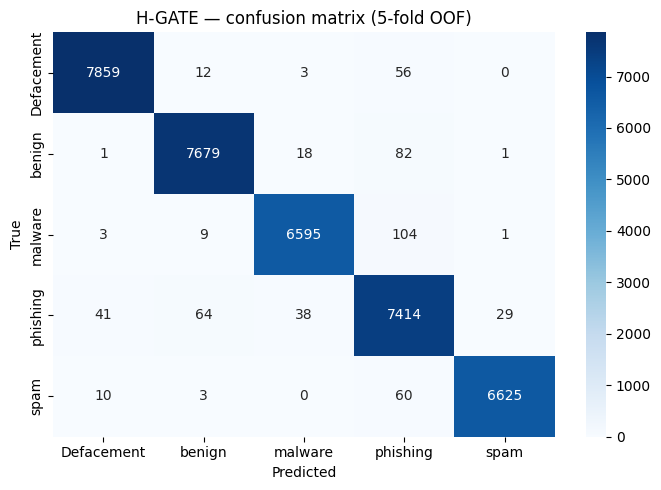


=== Per-class classification report ===
              precision    recall  f1-score   support

  Defacement     0.9931    0.9910    0.9920      7930
      benign     0.9887    0.9869    0.9878      7781
     malware     0.9911    0.9826    0.9868      6712
    phishing     0.9609    0.9773    0.9690      7586
        spam     0.9953    0.9891    0.9922      6698

    accuracy                         0.9854     36707
   macro avg     0.9858    0.9854    0.9856     36707
weighted avg     0.9855    0.9854    0.9855     36707



In [17]:
# Comparison table
all_results = baselines_results + [hgate_final]
res_df = pd.DataFrame(all_results).set_index('model')
print('\n=== Results summary (5-fold OOF) ===')
print(res_df.round(4).to_string())

# Confusion matrix for H-GATE
cm = confusion_matrix(y, pred_final, labels=list(range(N_CLASSES)))
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('H-GATE — confusion matrix (5-fold OOF)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# Per-class detailed report
print('\n=== Per-class classification report ===')
print(classification_report(y, pred_final, target_names=CLASSES, digits=4))


=== Per-class FPR (H-GATE) ===
  Defacement   FPR = 0.0019
  benign       FPR = 0.0030
  malware      FPR = 0.0020
  phishing     FPR = 0.0104
  spam         FPR = 0.0010


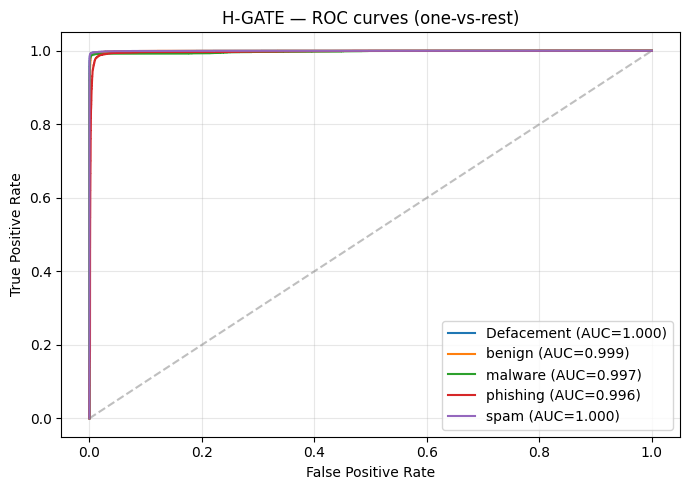

In [18]:
# Per-class FPR breakdown
def per_class_fpr(y_true, y_pred, n_classes):
    cm_ = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    out = {}
    for k in range(n_classes):
        FP = cm_[:, k].sum() - cm_[k, k]
        TN = cm_.sum() - cm_[k, :].sum() - cm_[:, k].sum() + cm_[k, k]
        out[CLASSES[k]] = FP / (FP + TN + 1e-12)
    return out

print('\n=== Per-class FPR (H-GATE) ===')
for k, v in per_class_fpr(y, pred_final, N_CLASSES).items():
    print(f'  {k:<12} FPR = {v:.4f}')

# ROC OvR per class
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(7, 5))
for k in range(N_CLASSES):
    y_bin = (y == k).astype(int)
    fpr_c, tpr_c, _ = roc_curve(y_bin, proba_final[:, k])
    plt.plot(fpr_c, tpr_c, label=f'{CLASSES[k]} (AUC={auc(fpr_c, tpr_c):.3f})')
plt.plot([0,1],[0,1],'--',color='gray', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('H-GATE — ROC curves (one-vs-rest)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 12 — SHAP interpretability (LightGBM branch)

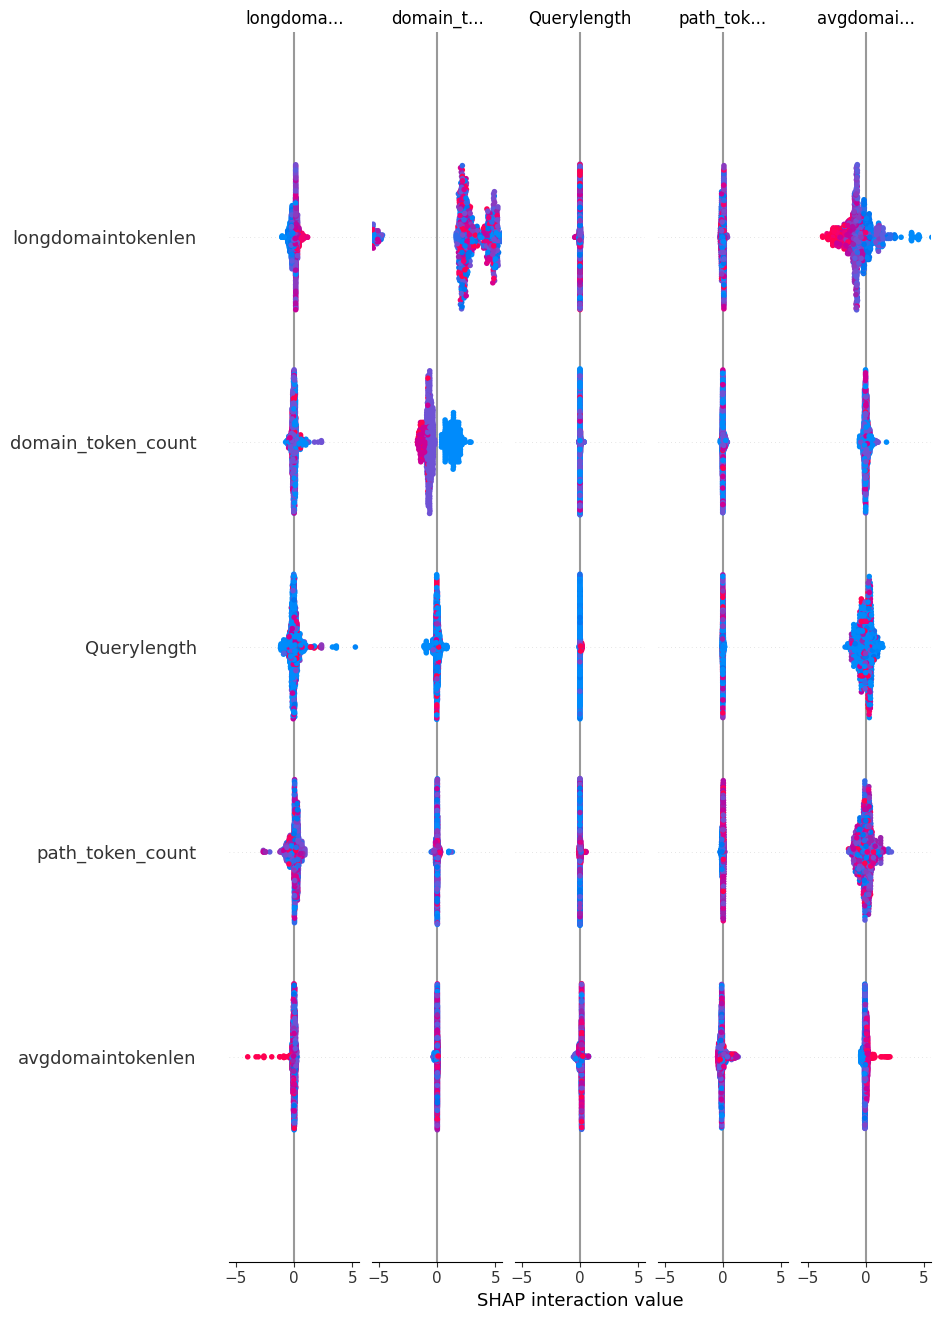

In [19]:
# Fit a single LightGBM on the full data (for interpretation only)
import shap
lgbm = lgb.LGBMClassifier(
    n_estimators=int(best_hp['lgb_rounds']),
    num_leaves=int(best_hp['lgb_leaves']),
    learning_rate=float(best_hp['lgb_lr']),
    class_weight='balanced', random_state=SEED, verbose=-1)
lgbm.fit(X, y)

explainer = shap.TreeExplainer(lgbm)
sv = explainer.shap_values(X.sample(min(1000, len(X)), random_state=SEED))
shap.summary_plot(sv, X.sample(min(1000, len(X)), random_state=SEED),
                  class_names=CLASSES, max_display=15, show=True)

## 13 — Save artifacts (for the report)

In [20]:
import joblib
ARTIFACT_DIR = os.path.join(PROJECT_DIR, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

res_df.to_csv(os.path.join(ARTIFACT_DIR, "results_summary.csv"))
with open(os.path.join(ARTIFACT_DIR, "best_hp.json"), "w") as f:
    json.dump({k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v) for k, v in best_hp.items()}, f, indent=2)
with open(os.path.join(ARTIFACT_DIR, "thresholds.json"), "w") as f:
    json.dump(dict(zip(CLASSES, [float(t) for t in thr_final])), f, indent=2)
np.save(os.path.join(ARTIFACT_DIR, "oof_proba.npy"), proba_final)

print(f"Saved to {ARTIFACT_DIR}")
print("\nH-GATE final metrics:")
print(f"   accuracy  = {hgate_final['acc']:.4f}")
print(f"   macro-F1  = {hgate_final['f1']:.4f}")
print(f"   macro-FPR = {hgate_final['fpr']:.4f}  <- minimized")
print(f"   macro-AUC = {hgate_final['auc']:.4f}")

Saved to /content/drive/MyDrive/hgate/artifacts

H-GATE final metrics:
   accuracy  = 0.9854
   macro-F1  = 0.9856
   macro-FPR = 0.0037  <- minimized
   macro-AUC = 0.9984
